# 🛡️ Stage 1: Indonesian Message Classification
### Multimodal Phishing Detection — Group 15, Binus University

**Tujuan:** Mendeteksi pesan phishing berbahasa Indonesia (WhatsApp/SMS) menggunakan TF-IDF + Logistic Regression.

**Pipeline:**
```
Load Data → Preprocessing → TF-IDF → Train Model → Evaluate → Save Results
```

---

## 📦 Cell 1: Install & Import Libraries

In [42]:
# Install libraries yang mungkin belum ada di Colab
!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import joblib
import warnings
warnings.filterwarnings('ignore')

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


## 📂 Cell 2: Mount Google Drive & Load Dataset

In [43]:

# ⚠️ SESUAIKAN path ini dengan lokasi file di Google Drive kalian
DATASET_PATH = 'D:\BINUS\Semester 4\RM\phising-detection\data\sms_spam_indo.csv'

# Load dataset
df = pd.read_csv(DATASET_PATH)

print(f'✅ Dataset berhasil di-load!')
print(f'📊 Total baris: {len(df)}')
print(f'📋 Kolom: {list(df.columns)}')
df.head(10)

✅ Dataset berhasil di-load!
📊 Total baris: 1143
📋 Kolom: ['Kategori', 'Pesan']


,Kategori,Pesan
0,spam,Plg Yth: Simcard anda mendptkan bonus poin plu...
1,ham,Iya ih ko sedih sih gtau kapan lg ke bandung :(
2,ham,Kalau mau bikin model/controller mending per a...
3,ham,Selamat nama1. Semoga selalu menempuh hidup ya...
4,spam,Tingkatkan nilai isi ulang Anda selanjutnya mi...
5,spam,Uangnya di Trnsfer di BNI ini aja a/n RASTINA ...
6,spam,PESAN RESMI Selamat NO Simcard anda M-dptkam h...
7,spam,"Sy RUDI di jambi, bgi tman2 yg sering kalah To..."
8,spam,Tri berBAGI bonus PULSA di bulan pernuh berkah...
9,ham,silahkan berkas dambil di ruang saya


## 🔍 Cell 3: Eksplorasi Data (EDA)

📊 Distribusi Label:
Kategori
spam    574
ham     569
Name: count, dtype: int64

0 = Aman, 1 = Phishing/Spam


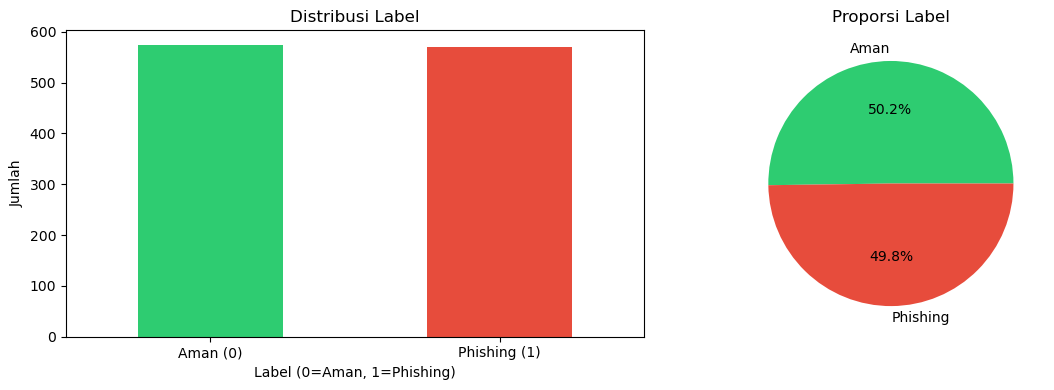

✅ Plot distribusi label disimpan!


In [44]:
# ⚠️ SESUAIKAN nama kolom ini setelah lihat output Cell 2
# Ganti 'text' dan 'label' dengan nama kolom yang sebenarnya di dataset kalian
TEXT_COL = 'Pesan'    # kolom berisi teks pesan
LABEL_COL = 'Kategori'  # kolom berisi label (0=aman, 1=phishing/spam)

# Rename kolom supaya konsisten
df = df.rename(columns={TEXT_COL: 'Pesan', LABEL_COL: 'Kategori'})

# Cek distribusi label
print('📊 Distribusi Label:')
print(df['Kategori'].value_counts())
print(f'\n0 = Aman, 1 = Phishing/Spam')

# Visualisasi distribusi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['Kategori'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Label')
axes[0].set_xlabel('Label (0=Aman, 1=Phishing)')
axes[0].set_ylabel('Jumlah')
axes[0].set_xticklabels(['Aman (0)', 'Phishing (1)'], rotation=0)

# Pie chart
df['Kategori'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Aman', 'Phishing'], colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%')
axes[1].set_title('Proporsi Label')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('stage1_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot distribusi label disimpan!')

## 🧹 Cell 4: Preprocessing Text

In [45]:
import re

def preprocess_text(text):
    """Bersihkan teks pesan untuk NLP."""
    if pd.isna(text):
        return ''
    text = str(text).lower()              # lowercase
    text = re.sub(r'http\S+', 'URL', text)  # ganti URL dengan token 'URL'
    text = re.sub(r'\d+', 'NUM', text)    # ganti angka dengan token 'NUM'
    text = re.sub(r'[^\w\s]', ' ', text)  # hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()  # hapus spasi berlebih
    return text

# Terapkan preprocessing
df['text_clean'] = df['Pesan'].apply(preprocess_text)

# Hapus baris kosong
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)

# Cek missing values
print('🔍 Missing values setelah preprocessing:')
print(df[['text_clean', 'Kategori']].isnull().sum())
print(f'\n✅ Total data bersih: {len(df)} baris')

# Contoh hasil preprocessing
print('\n📝 Contoh hasil preprocessing:')
print(df[['Pesan', 'text_clean', 'Kategori']].head(5).to_string())


🔍 Missing values setelah preprocessing:
text_clean    0
Kategori      0
dtype: int64

✅ Total data bersih: 1143 baris

📝 Contoh hasil preprocessing:
                                                                                                                                                         Pesan                                                                                                                                                text_clean Kategori
0  Plg Yth: Simcard anda mendptkan bonus poin plus-plus 555 dr:PT.INDOSAT pin anda:277fg49 u/info klik di www.indosat-555.blogspot.com atau Hub:021-3338-0074.  plg yth simcard anda mendptkan bonus poin plus plus NUM dr pt indosat pin anda NUMfgNUM u info klik di www indosat NUM blogspot com atau hub NUM NUM NUM     spam
1                                                                                                              Iya ih ko sedih sih gtau kapan lg ke bandung :(                                                 

## ✂️ Cell 5: Split Data Train & Test

In [48]:
X = df['text_clean']
y = df['Kategori']

# Split 80% train, 20% test — stratified supaya proporsi label sama
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'📊 Ukuran data:')
print(f'  Training set : {len(X_train)} baris')
print(f'  Testing set  : {len(X_test)} baris')
print(f'\n📊 Distribusi label di training set:')
print(y_train.value_counts())
print(f'\n📊 Distribusi label di testing set:')
print(y_test.value_counts())

📊 Ukuran data:
  Training set : 914 baris
  Testing set  : 229 baris

📊 Distribusi label di training set:
Kategori
spam    459
ham     455
Name: count, dtype: int64

📊 Distribusi label di testing set:
Kategori
spam    115
ham     114
Name: count, dtype: int64


## 🔢 Cell 6: TF-IDF Vectorization

In [49]:
# Inisialisasi TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,      # ambil 5000 kata paling penting
    ngram_range=(1, 2),     # unigram + bigram (ex: 'selamat', 'selamat hadiah')
    min_df=2,               # abaikan kata yang muncul < 2x
    sublinear_tf=True       # normalisasi frekuensi
)

# Fit pada training data saja (JANGAN fit pada test data — data leakage!)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'✅ TF-IDF selesai!')
print(f'📊 Shape training matrix : {X_train_tfidf.shape}')
print(f'📊 Shape testing matrix  : {X_test_tfidf.shape}')
print(f'\n🔑 Contoh fitur TF-IDF (20 pertama):')
print(tfidf.get_feature_names_out()[:20])

✅ TF-IDF selesai!
📊 Shape training matrix : (914, 3146)
📊 Shape testing matrix  : (229, 3146)

🔑 Contoh fitur TF-IDF (20 pertama):
['aa' 'aamiin' 'abis' 'abis maghrib' 'ad' 'ada' 'ada daging' 'ada di'
 'ada masalah' 'ada murid' 'ada nama' 'ada num' 'ada paket'
 'ada perubahan' 'ada promo' 'ada tgl' 'ada yang' 'ada yg' 'adalah'
 'adalah num']


## 🤖 Cell 7: Training Model Logistic Regression

In [50]:
# Inisialisasi dan training model
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0               # regularization strength
)

model.fit(X_train_tfidf, y_train)

print('✅ Model berhasil ditraining!')

✅ Model berhasil ditraining!


## 📊 Cell 8: Evaluasi Model

In [51]:
# Prediksi pada test set
y_pred = model.predict(X_test_tfidf)
y_prob = model.predict_proba(X_test_tfidf)

# Hitung semua metrik
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print('=' * 50)
print('📊 HASIL EVALUASI — STAGE 1: MESSAGE CLASSIFIER')
print('=' * 50)
print(f'Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print('=' * 50)
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Aman (0)', 'Phishing (1)']))

# Simpan metrik ke dictionary (untuk nanti dibandingkan dengan stage lain)
stage1_metrics = {
    'Stage': 'Stage 1 - Message',
    'Model': 'TF-IDF + Logistic Regression',
    'Accuracy': round(accuracy, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-Score': round(f1, 4)
}
print('\n✅ Metrik disimpan untuk tabel perbandingan nanti!')

📊 HASIL EVALUASI — STAGE 1: MESSAGE CLASSIFIER
Accuracy  : 0.9825 (98.25%)
Precision : 0.9827
Recall    : 0.9825
F1-Score  : 0.9825

📋 Classification Report:
              precision    recall  f1-score   support

    Aman (0)       0.99      0.97      0.98       114
Phishing (1)       0.97      0.99      0.98       115

    accuracy                           0.98       229
   macro avg       0.98      0.98      0.98       229
weighted avg       0.98      0.98      0.98       229


✅ Metrik disimpan untuk tabel perbandingan nanti!


## 🗺️ Cell 9: Confusion Matrix

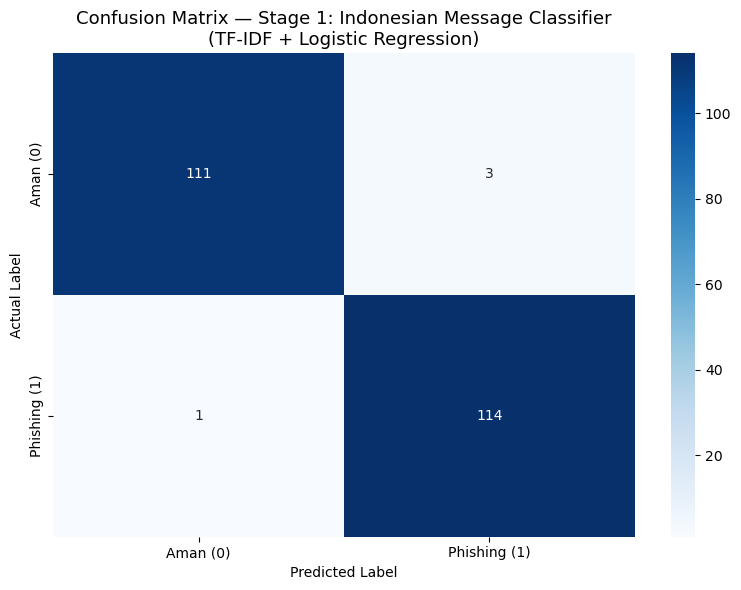


📊 Detail Confusion Matrix:
  True Negative  (Aman diprediksi Aman)     : 111
  False Positive (Aman diprediksi Phishing)  : 3
  False Negative (Phishing diprediksi Aman)  : 1
  True Positive  (Phishing diprediksi Phish) : 114

✅ Confusion matrix disimpan ke stage1_confusion_matrix.png


In [52]:
# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Aman (0)', 'Phishing (1)'],
    yticklabels=['Aman (0)', 'Phishing (1)']
)
plt.title('Confusion Matrix — Stage 1: Indonesian Message Classifier\n(TF-IDF + Logistic Regression)', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('stage1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretasi
tn, fp, fn, tp = cm.ravel()
print(f'\n📊 Detail Confusion Matrix:')
print(f'  True Negative  (Aman diprediksi Aman)     : {tn}')
print(f'  False Positive (Aman diprediksi Phishing)  : {fp}')
print(f'  False Negative (Phishing diprediksi Aman)  : {fn}')
print(f'  True Positive  (Phishing diprediksi Phish) : {tp}')
print(f'\n✅ Confusion matrix disimpan ke stage1_confusion_matrix.png')

## 🔑 Cell 10: Top Phishing Keywords (untuk bahan Discussion)

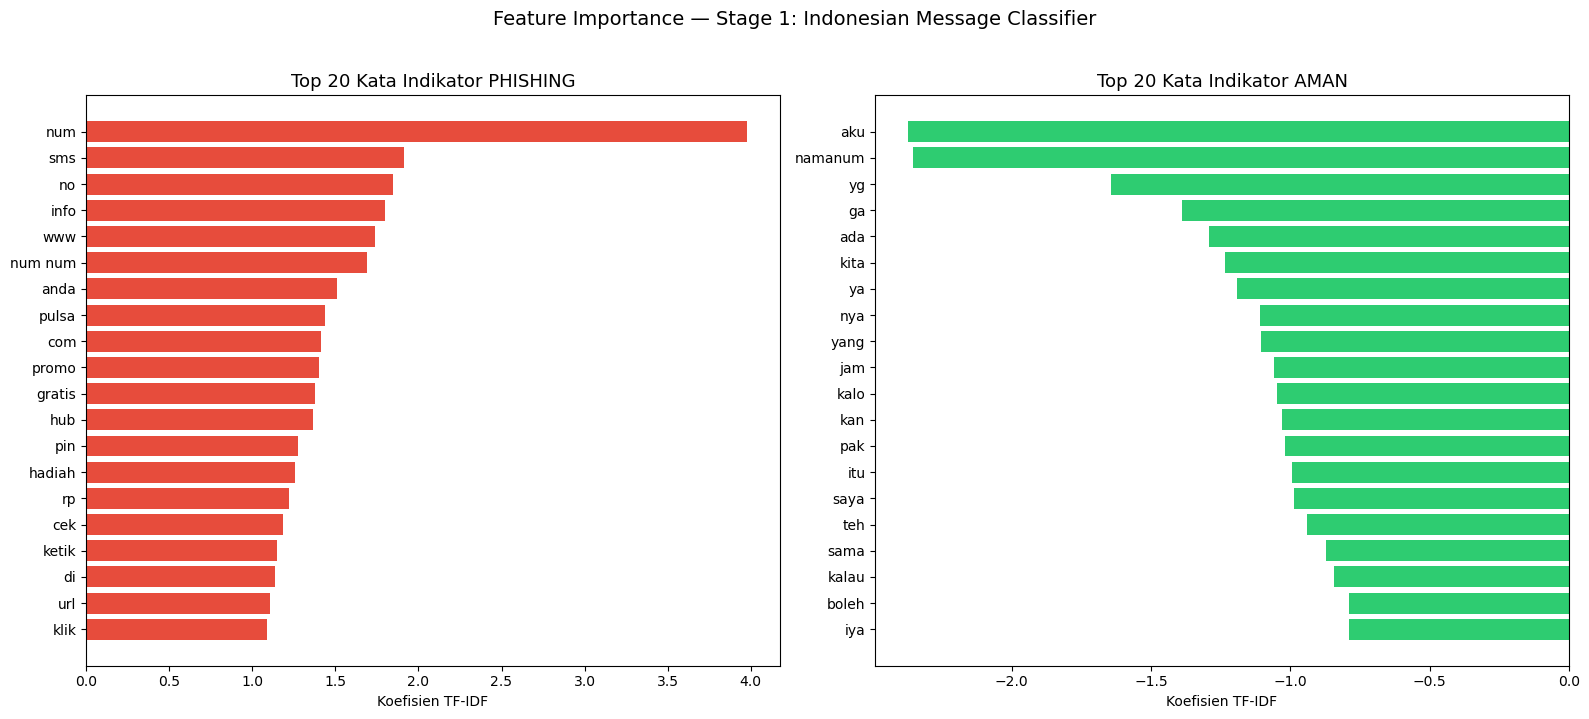


🔑 Top 20 Phishing Keywords:
  num                            → 3.9766
  sms                            → 1.9154
  no                             → 1.8446
  info                           → 1.7980
  www                            → 1.7412
  num num                        → 1.6922
  anda                           → 1.5073
  pulsa                          → 1.4378
  com                            → 1.4166
  promo                          → 1.4002
  gratis                         → 1.3805
  hub                            → 1.3682
  pin                            → 1.2735
  hadiah                         → 1.2561
  rp                             → 1.2200
  cek                            → 1.1834
  ketik                          → 1.1513
  di                             → 1.1387
  url                            → 1.1085
  klik                           → 1.0898

✅ Plot keywords disimpan ke stage1_top_keywords.png


In [53]:
# Ambil koefisien model untuk kelas phishing (label=1)
feature_names = tfidf.get_feature_names_out()
coef = model.coef_[0]

# Top 20 kata yang paling kuat menandakan PHISHING
top_phishing_idx = coef.argsort()[-20:][::-1]
top_phishing_words = [(feature_names[i], coef[i]) for i in top_phishing_idx]

# Top 20 kata yang paling kuat menandakan AMAN
top_safe_idx = coef.argsort()[:20]
top_safe_words = [(feature_names[i], coef[i]) for i in top_safe_idx]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Phishing keywords
words_p, scores_p = zip(*top_phishing_words)
axes[0].barh(range(20), scores_p, color='#e74c3c')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(words_p)
axes[0].set_title('Top 20 Kata Indikator PHISHING', fontsize=13)
axes[0].set_xlabel('Koefisien TF-IDF')
axes[0].invert_yaxis()

# Safe keywords
words_s, scores_s = zip(*top_safe_words)
axes[1].barh(range(20), scores_s, color='#2ecc71')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(words_s)
axes[1].set_title('Top 20 Kata Indikator AMAN', fontsize=13)
axes[1].set_xlabel('Koefisien TF-IDF')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance — Stage 1: Indonesian Message Classifier', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('stage1_top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔑 Top 20 Phishing Keywords:')
for word, score in top_phishing_words:
    print(f'  {word:30s} → {score:.4f}')

print('\n✅ Plot keywords disimpan ke stage1_top_keywords.png')

## 🚦 Cell 11: Simulasi Latency-Aware (Ambiguous Threshold)

In [54]:
# Simulasi: berapa banyak pesan yang bisa langsung diklasifikasi di Stage 1
# vs. yang harus dilanjutkan ke Stage 2 (ambiguous)

CONFIDENCE_THRESHOLD = 0.70  # kalau confidence < 70% → ambiguous → lanjut ke Stage 2

max_prob = y_prob.max(axis=1)  # confidence tertinggi per prediksi

clear_phishing  = ((y_pred == 1) & (max_prob >= CONFIDENCE_THRESHOLD)).sum()
clear_safe      = ((y_pred == 0) & (max_prob >= CONFIDENCE_THRESHOLD)).sum()
ambiguous       = (max_prob < CONFIDENCE_THRESHOLD).sum()
total           = len(y_pred)

print('=' * 55)
print('🚦 SIMULASI LATENCY-AWARE — STAGE 1')
print('=' * 55)
print(f'Confidence threshold : {CONFIDENCE_THRESHOLD*100:.0f}%')
print(f'Total pesan test     : {total}')
print(f'─' * 55)
print(f'✅ Langsung AMAN (stop di Stage 1)     : {clear_safe:4d} ({clear_safe/total*100:.1f}%)')
print(f'🚨 Langsung PHISHING (stop di Stage 1) : {clear_phishing:4d} ({clear_phishing/total*100:.1f}%)')
print(f'❓ AMBIGUOUS → lanjut ke Stage 2       : {ambiguous:4d} ({ambiguous/total*100:.1f}%)')
print('=' * 55)
print(f'\n💡 Artinya: {(total-ambiguous)/total*100:.1f}% pesan bisa diselesaikan di Stage 1 saja!')
print(f'   Hanya {ambiguous/total*100:.1f}% yang perlu analisis URL lebih lanjut.')

🚦 SIMULASI LATENCY-AWARE — STAGE 1
Confidence threshold : 70%
Total pesan test     : 229
───────────────────────────────────────────────────────
✅ Langsung AMAN (stop di Stage 1)     :    0 (0.0%)
🚨 Langsung PHISHING (stop di Stage 1) :    0 (0.0%)
❓ AMBIGUOUS → lanjut ke Stage 2       :   36 (15.7%)

💡 Artinya: 84.3% pesan bisa diselesaikan di Stage 1 saja!
   Hanya 15.7% yang perlu analisis URL lebih lanjut.


## 💾 Cell 12: Simpan Model & Hasil

In [55]:
# Simpan model dan vectorizer
joblib.dump(model, 'stage1_model_lr.pkl')
joblib.dump(tfidf, 'stage1_tfidf_vectorizer.pkl')

# Simpan metrik ke CSV
metrics_df = pd.DataFrame([stage1_metrics])
metrics_df.to_csv('stage1_metrics.csv', index=False)

print('💾 File yang disimpan:')
print('  ✅ stage1_model_lr.pkl           ← model Logistic Regression')
print('  ✅ stage1_tfidf_vectorizer.pkl   ← TF-IDF vectorizer')
print('  ✅ stage1_metrics.csv            ← hasil evaluasi')
print('  ✅ stage1_confusion_matrix.png   ← confusion matrix')
print('  ✅ stage1_top_keywords.png       ← phishing keywords')
print('  ✅ stage1_label_distribution.png ← distribusi label')

print('\n' + '=' * 55)
print('🎉 STAGE 1 SELESAI!')
print('=' * 55)
print(f'\n📊 Ringkasan hasil:')
print(f'  Accuracy  : {stage1_metrics["Accuracy"]*100:.2f}%')
print(f'  Precision : {stage1_metrics["Precision"]*100:.2f}%')
print(f'  Recall    : {stage1_metrics["Recall"]*100:.2f}%')
print(f'  F1-Score  : {stage1_metrics["F1-Score"]*100:.2f}%')
print('\n➡️  Lanjut ke: 02_url_classification.ipynb')

💾 File yang disimpan:
  ✅ stage1_model_lr.pkl           ← model Logistic Regression
  ✅ stage1_tfidf_vectorizer.pkl   ← TF-IDF vectorizer
  ✅ stage1_metrics.csv            ← hasil evaluasi
  ✅ stage1_confusion_matrix.png   ← confusion matrix
  ✅ stage1_top_keywords.png       ← phishing keywords
  ✅ stage1_label_distribution.png ← distribusi label

🎉 STAGE 1 SELESAI!

📊 Ringkasan hasil:
  Accuracy  : 98.25%
  Precision : 98.27%
  Recall    : 98.25%
  F1-Score  : 98.25%

➡️  Lanjut ke: 02_url_classification.ipynb


---
## 📝 Catatan untuk Paper (Result & Discussion)

Setelah notebook ini selesai dijalankan, gunakan output berikut untuk bagian **Result**:
- Tabel metrik dari Cell 8 (Accuracy, Precision, Recall, F1)
- Gambar confusion matrix dari Cell 9
- Gambar top keywords dari Cell 10

Untuk bagian **Discussion**, angkat poin-poin ini:
1. Keyword apa saja yang paling dominan sebagai indikator phishing? (lihat Cell 10)
2. Apakah kata seperti "selamat", "hadiah", "klik" muncul di top keywords?
3. Berapa persen pesan yang bisa langsung diklasifikasi tanpa perlu analisis URL? (lihat Cell 11)
4. Apa limitasi model ini? (tidak menangkap konteks, hanya keyword-based)